In [1]:
%load_ext autoreload
%autoreload 2

import os
# Workaround for Mac M1 OpenMP conflict when loading torch
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#import pytorch_lightning as pl
import pandas as pd
import numpy as np
import pickle


from scipy import stats

import matplotlib.pyplot as plt

from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from footprinting import plot_count_matrix, get_count_matrix, average_counts_by_fraglen, counts_by_fraglen, get_footprint_and_procap, get_valid_windows, detect_blobs_matrix, detect_footprints, most_common_fragment_length

from datasets import FootprintDataModule
from models    import UNetLightning
from functools import partial
import wandb


In [2]:
# Define test input data 
#counts_gz = '../data/MicroC_3hrDMSO.counts.tsv.gz'
counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
#counts_gz = '../test_data/mesc_microc_test.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'

chrom = 'chr8'

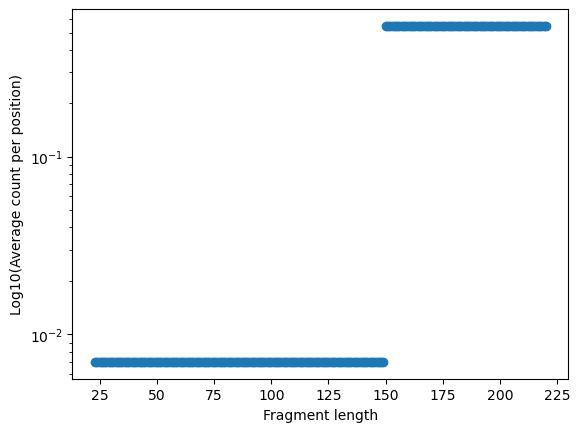

In [3]:
# Get normalization factors (i.e. average counts per fragment length)

avg_by_len = average_counts_by_fraglen(counts_gz, chrom, gap_thresh=5000, num_regions=500, region_size=5000)

# Save avg_by_len to file
#with open('../data/avg_by_len.pkl', 'wb') as f:
#    pickle.dump(avg_by_len, f)

# Load avg_by_len from file
#with open('../data/avg_by_len.pkl', 'rb') as f:
#    avg_by_len = pickle.load(f)

# Plot log10(avg_by_len) - scatter plot
plt.scatter(avg_by_len.keys(), list(avg_by_len.values()))
plt.yscale('log')
plt.xlabel('Fragment length')
plt.ylabel('Log10(Average count per position)')
plt.show()


[('chr8', 23230000, 23230999), ('chr8', 23231000, 23231999), ('chr8', 23232000, 23232999), ('chr8', 23233000, 23233999), ('chr8', 23234000, 23234999), ('chr8', 23235000, 23235999), ('chr8', 23236000, 23236999), ('chr8', 23237000, 23237999), ('chr8', 23238000, 23238999), ('chr8', 23239000, 23239999)]


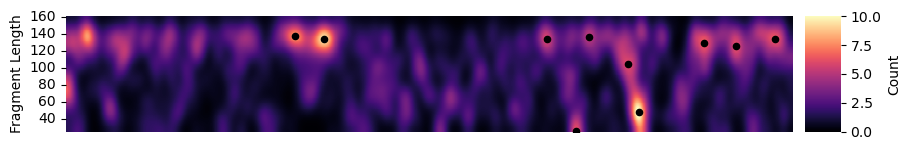

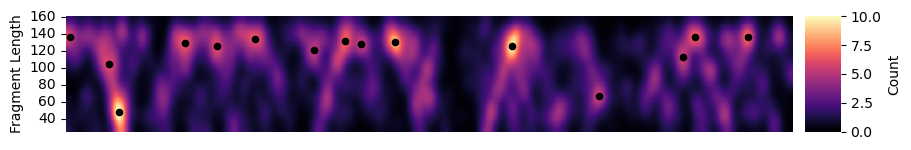

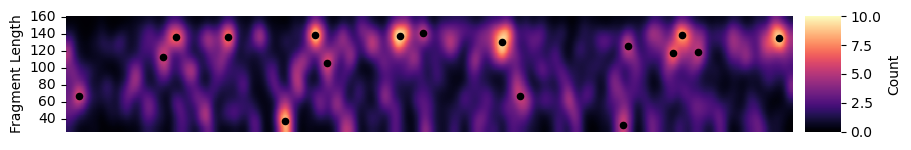

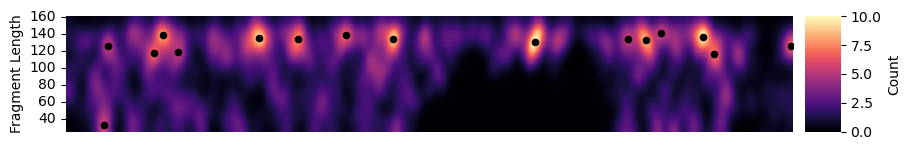

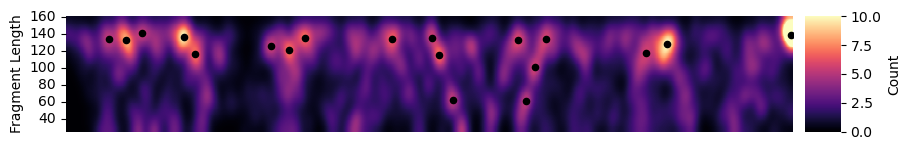

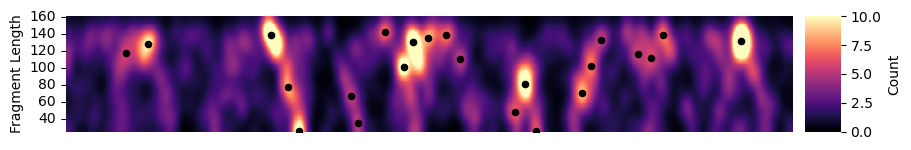

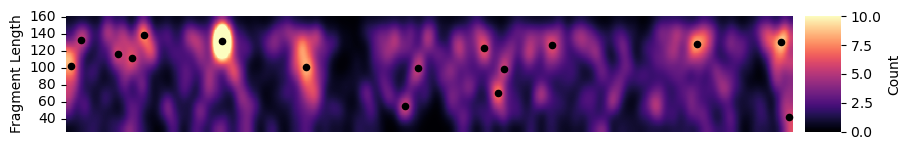

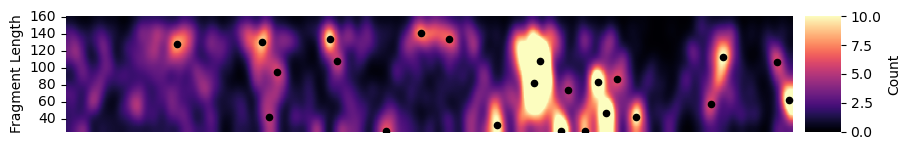

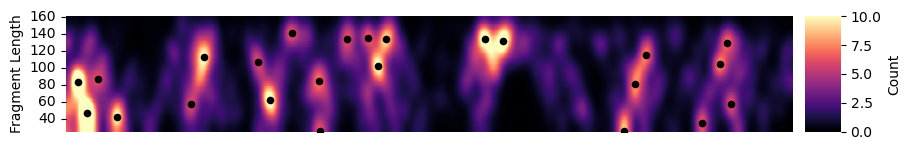

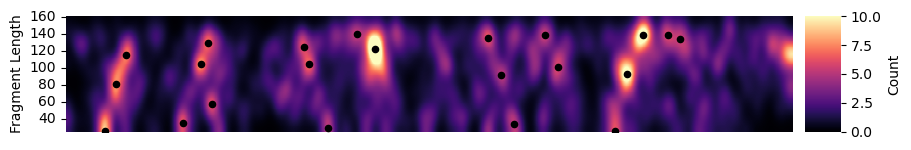

   fragment_length  position    size  max_signal  mean_signal  total_signal
0               47  23230902  1302.0   10.422411     7.182189   9351.210441
1              134  23230297  1308.0    9.561851     6.828927   8932.236999
2              137  23230241   874.0    7.636759     6.132499   5359.804022
3               25  23230782   154.0    6.204888     5.575554    858.635331
4              104  23230882   740.0    5.902511     5.387846   3987.005842


In [7]:
# Loop over a set of windows 

# Set parameters for blob detection
threshold = 5  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels

chrom = 'chr8'
start_bp = 23_230_000
end_bp = 23_240_000

window_size = 1000
pad = 200

# Make windows from start_bp to end_bp with a 500bp overlap
windows = []
for i in range(start_bp, end_bp, window_size):
    windows.append((chrom, i, i+window_size-1))

print(windows)

# Loop over windows
# Initialize blobs as an empty DataFrame before the loop (outside the loop)
footprints = pd.DataFrame()

for chrom, window_start, window_end in windows:
    footprint, _ = get_count_matrix(counts_gz, chrom, window_start-pad, window_end+pad, fragment_len_min=25, fragment_len_max=160, scale_factor_dict=avg_by_len, sigma=10)
    # Detect blobs in the footprint matrix
    window_blobs = detect_blobs_matrix(
        footprint_matrix=footprint,
        threshold=threshold, min_size=min_size
    )
    # Subset to blobs within (unpadded) window
    window_blobs = window_blobs[(window_blobs['position'] >= window_start) & (window_blobs['position'] <= window_end)]
    # Append window_blobs to blobs
    footprints = pd.concat([footprints, window_blobs], ignore_index=True)
    
    plot_count_matrix(footprint, blobs=blobs, blob_marker='o', blob_color='black', blob_size=20, 
                      xtick_spacing=500, figsize=(10, 1.5), vmax=10)

print(footprints.head())


In [21]:
# Detect footprints in a larger region
footprints = detect_footprints(counts_gz, chromosomes=[(chrom, 20_000_000, 30_000_000)], window_size=10000, pad=200, threshold=5, sigma=10, min_size=5, 
                               fragment_len_min=25, fragment_len_max=160, scale_factor_dict=avg_by_len, num_cores=8)

Getting valid windows...
Processing 853 windows using 8 cores...


Detecting footprints: 100%|██████████| 853/853 [00:17<00:00, 48.73it/s]


Detected 24179 footprints across 853 windows.


   max_signal   p_value   q_value
0   10.263562  0.049373  0.489859
1    7.876501  0.208446  0.791211
2    5.976315  0.613212  0.981840
3    5.288962  0.876707  0.996174
4    7.876501  0.208446  0.791211
5    6.382521  0.490839  0.950656
6    6.021988  0.598243  0.979211
7    5.752227  0.691300  0.993732
8    5.397943  0.830434  0.996174
9    5.133867  0.944222  0.996174
Number significant at 5% FDR: 310
Number significant at 10% FDR: 478


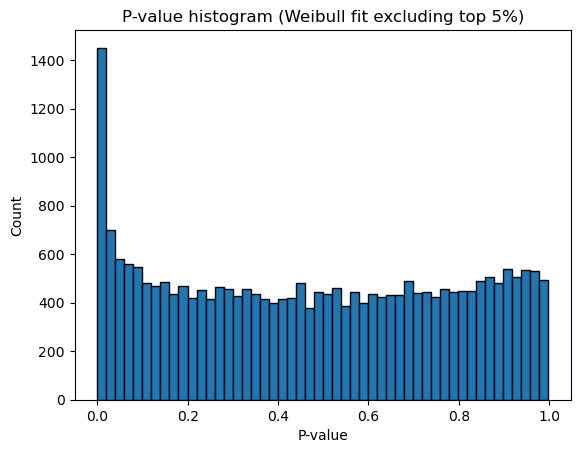

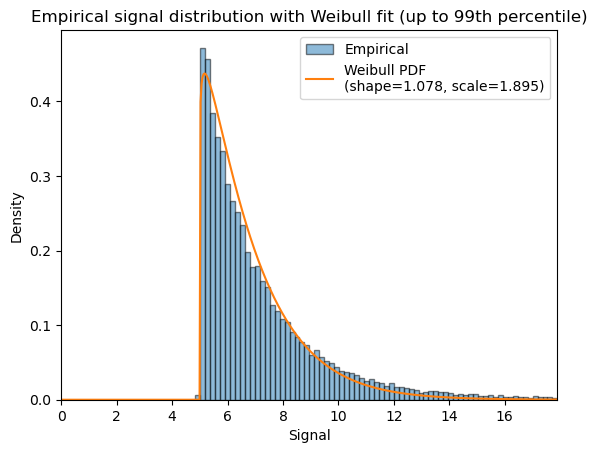

In [24]:
# Fit a Weibull distribution to the max_signal values and use it to compute p-values


# 1. 
values = footprints['max_signal'].values 

# If there are more than 100,000 footprints, use a random subsample
value_sample = values if len(values) <= 100_000 else np.random.choice(values, 100_000, replace=False)

# 2. Grid search over specified exclusion fractions
candidates = [0.05, 0.10, 0.20, 0.30]
results = []
for f in candidates:
    thr = np.percentile(values, 100 * (1 - f))
    bulk = value_sample[value_sample <= thr]
    shape, loc, scale = stats.weibull_min.fit(bulk, floc=threshold)
    p_bulk = 1 - stats.weibull_min.cdf(bulk, shape, loc=threshold, scale=scale)
    ks_stat, _ = stats.kstest(p_bulk, 'uniform')
    results.append((f, thr, shape, scale, ks_stat))

# 3. Select best fraction (min KS statistic)
best_f, best_thr, best_shape, best_scale, best_ks = min(results, key=lambda x: x[4])

# 4. Refit on bulk with best fraction
bulk = value_sample[value_sample <= best_thr]
shape, loc, scale = stats.weibull_min.fit(bulk, floc=threshold)

# 5a. Compute p-values for all data points
footprints['p_value'] = 1 - stats.weibull_min.cdf(values, shape, loc=threshold, scale=scale)

# 5b. Compute q-values (Benjamini-Hochberg)
#footprints['q_value'] = stats.multipletests(footprints['p_value'], method='fdr_bh')[1]

from statsmodels.stats.multitest import multipletests
rejected, qvals, _, _ = multipletests(footprints['p_value'], alpha=0.05, method='fdr_bh')
footprints['q_value'] = qvals

# 6. Show first few rows with p-values
print(footprints[['max_signal', 'p_value', 'q_value']].head(10))

# Number significant at 5%
print(f"Number significant at 5% FDR: {np.sum(footprints['q_value'] <= 0.05)}")
# Number significant at 10%
print(f"Number significant at 10% FDR: {np.sum(footprints['q_value'] <= 0.10)}")

# 7. Plot histogram of all p-values
plt.figure()
plt.hist(footprints['p_value'], bins=50, edgecolor='black')
plt.xlabel('P-value')
plt.ylabel('Count')
plt.title(f'P-value histogram (Weibull fit excluding top {int(best_f*100)}%)')
plt.show()

# 8. Empirical distribution with Weibull PDF, x-axis up to ~25 (99.8th percentile)
x_limit = np.percentile(values, 99)
plt.figure()
# Histogram of empirical signals up to x_limit
count, bins, _ = plt.hist(value_sample, bins=100, density=True, alpha=0.5, edgecolor='black', range=(0, x_limit), label='Empirical')
# Weibull PDF curve over same range
x = np.linspace(0, x_limit, 500)
pdf = stats.weibull_min.pdf(x, shape, loc=threshold, scale=scale)
plt.plot(x, pdf, label=f'Weibull PDF\n(shape={shape:.3f}, scale={scale:.3f})')
plt.xlim(0, x_limit)
plt.xlabel('Signal')
plt.ylabel('Density')
plt.title('Empirical signal distribution with Weibull fit (up to 99th percentile)')
plt.legend()
plt.show()


Detected 5 blobs

Blob statistics:
  Mean size: 806.8 pixels
  Mean signal: 13.36
  Total signal: 63427.51

Top 5 blobs by total signal:
  1. Position: 23237712.0, Fragment length: 108.0, Size: 1774.0, Total signal: 31079.71
  2. Position: 23237701.0, Fragment length: 82.0, Size: 1488.0, Total signal: 23560.97
  3. Position: 23237840.0, Fragment length: 46.0, Size: 426.0, Total signal: 4997.83
  4. Position: 23237823.0, Fragment length: 82.0, Size: 243.0, Total signal: 2696.78
  5. Position: 23237753.0, Fragment length: 23.0, Size: 103.0, Total signal: 1092.22


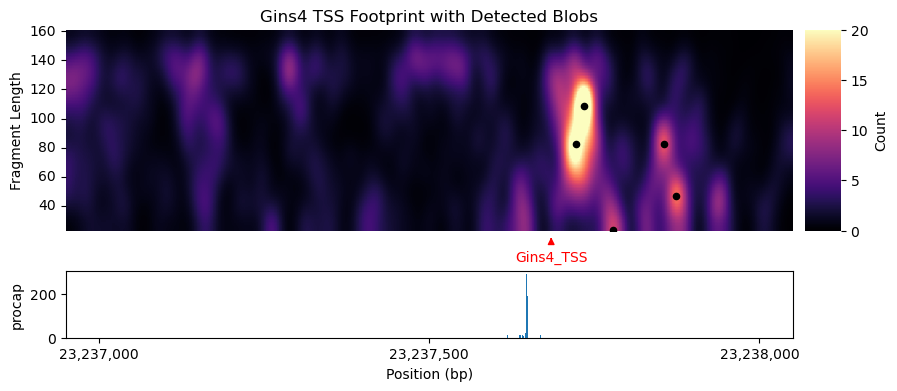

(131, 1001) (131,) (1001,)


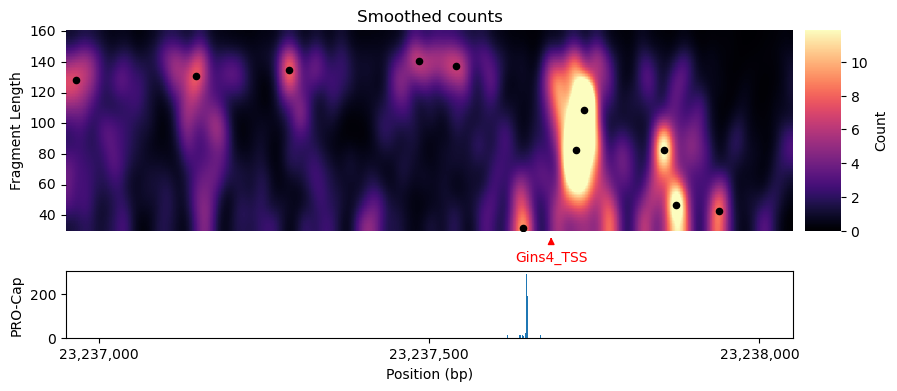

In [ ]:

# Visualize a small region with detected footprints

chrom = 'chr8'
start_bp = 23_237_000
end_bp = 23_238_000

markers = {
    23_237_668: 'Gins4_TSS'
}

footprint, raw_total_counts, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw,
                                avg_count_per_fragment_length=avg_by_len,
                                fragment_len_min=30, fragment_len_max=160,
                                chrom=chrom, window_start=start_bp, window_end=end_bp, footprint_sigma=10)

# Print footprint and procap shape
print(footprint.shape, raw_total_counts.shape, procap.shape)

plot_count_matrix(footprint, named_positions=markers, tracks = {'PRO-Cap': procap}, 
                  title='Smoothed counts', xtick_spacing=500,
                  blobs = footprints, blob_color='black', blob_size=20)

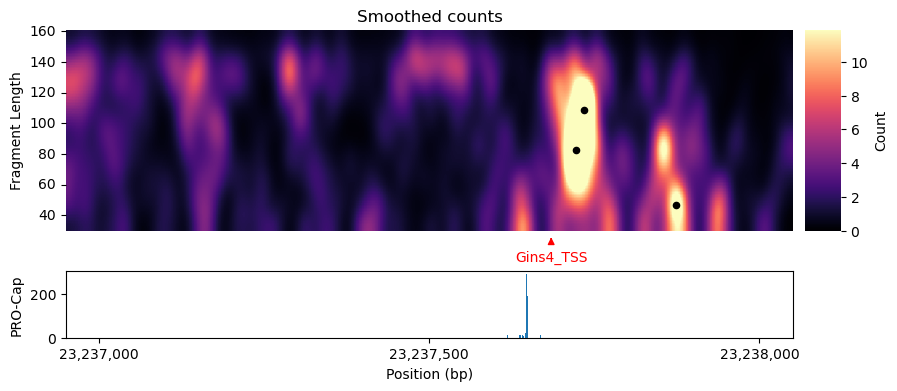

In [16]:
plot_count_matrix(footprint, named_positions=markers, tracks = {'PRO-Cap': procap}, 
                  title='Smoothed counts', xtick_spacing=500,
                  blobs = footprints[footprints["q_value"] <= 0.2], blob_color='black', blob_size=20)

(136, 3001) (136,) (3001,)


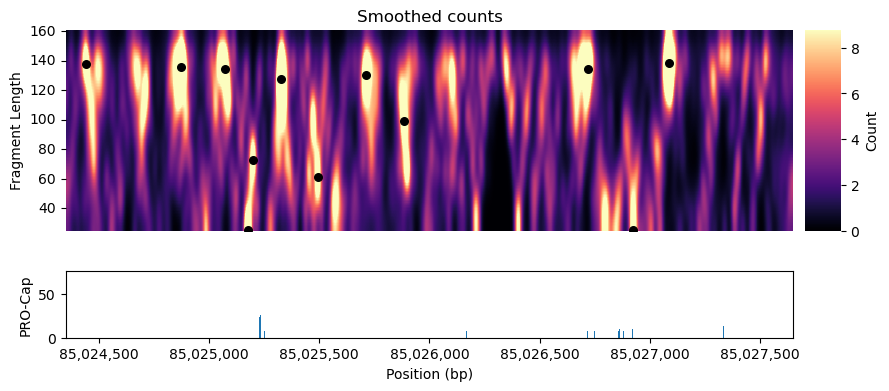

In [17]:
# Visualize another region with detected footprints

chrom = 'chr8'
start_bp = 85_024_500
end_bp = 85_027_500

footprint, raw_total_counts, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw,
                                avg_count_per_fragment_length=avg_by_len,
                                fragment_len_min=25, fragment_len_max=160,
                                chrom=chrom, window_start=start_bp, window_end=end_bp, footprint_sigma=10)

# Print footprint and procap shape
print(footprint.shape, raw_total_counts.shape, procap.shape)

plot_count_matrix(footprint, tracks = {'PRO-Cap': procap}, 
                  title='Smoothed counts', xtick_spacing=500,
                  blobs = footprints[footprints["q_value"] <= 0.2], blob_color='black', blob_size=30)


Benchmarking window size: 1,000 bp
Processing 10000 windows...
Window size: 1,000 bp
Number of windows: 10000
Processing time: 479.89 seconds
Peak memory usage: 14.72 MB
Number of blobs detected: 21699

Benchmarking window size: 5,000 bp
Processing 2000 windows...
Window size: 5,000 bp
Number of windows: 2000
Processing time: 180.14 seconds
Peak memory usage: 119.44 MB
Number of blobs detected: 21699

Benchmarking window size: 10,000 bp
Processing 1000 windows...
Window size: 10,000 bp
Number of windows: 1000
Processing time: 142.25 seconds
Peak memory usage: 40.59 MB
Number of blobs detected: 21699

Benchmarking window size: 25,000 bp
Processing 400 windows...
Window size: 25,000 bp
Number of windows: 400
Processing time: 127.97 seconds
Peak memory usage: 168.69 MB
Number of blobs detected: 21699

Benchmarking window size: 50,000 bp
Processing 200 windows...
Window size: 50,000 bp
Number of windows: 200
Processing time: 122.81 seconds
Peak memory usage: 404.89 MB
Number of blobs dete

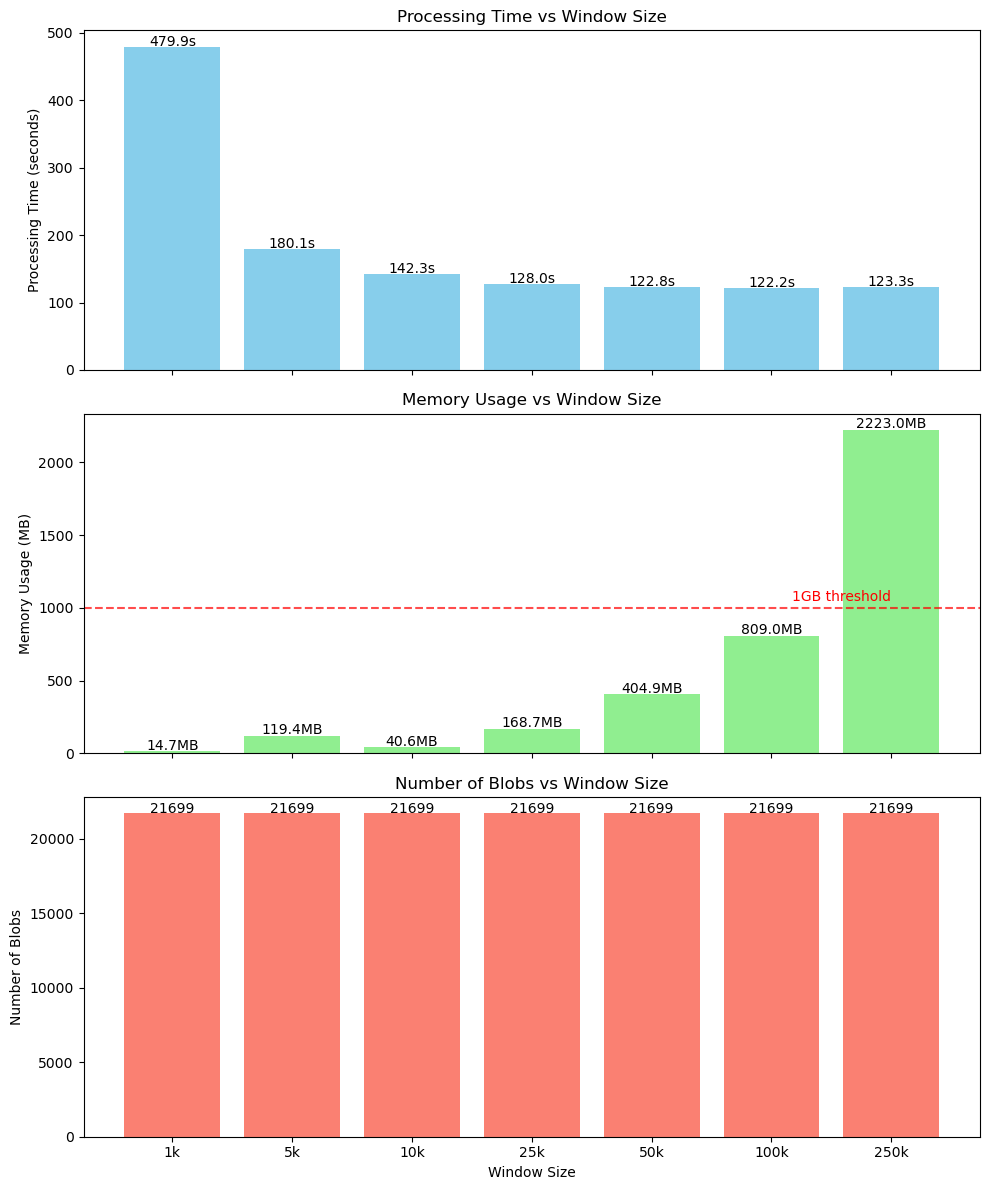


Optimal window size: 100,000.0 bp
Processing time: 122.22 seconds
Memory usage: 808.95 MB
Number of blobs: 21699.0

This window size provides the best balance between processing speed and memory usage while staying under 1GB.


In [18]:
# Benchmark different window sizes for blob detection across a large genomic region
# Using a fixed 200bp overlap between adjacent windows to ensure consistent detection of features at window boundaries
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage

def process_region_with_window(chrom, start, end, window_size, pad=200, threshold=5.0, sigma=1.0, min_size=5):
    """
    Process a genomic region using sliding windows of specified size.
    Windows have a fixed 200bp overlap between adjacent windows.
    
    Parameters
    ----------
    chrom : str
        Chromosome name
    start : int
        Start position of the region
    end : int
        End position of the region
    window_size : int
        Size of each window in base pairs
    pad : int
        Padding to add to each side of the window
    threshold : float
        Threshold for blob detection
    sigma : float
        Sigma for Gaussian smoothing in blob detection
    min_size : int
        Minimum blob size in pixels
        
    Returns
    -------
    tuple
        (all_blobs, processing_time, max_memory)
    """
    # Create windows
    windows = []
    for i in range(start, end, window_size):
        window_end = min(i + window_size-1, end)
        windows.append((chrom, i, window_end))
    
    # Initialize empty DataFrame for blobs
    all_blobs = pd.DataFrame()
    
    # Start timing
    start_time = time.time()
    
    # Define the function to be memory profiled
    def process_windows():
        nonlocal all_blobs
        for chrom, window_start, window_end in windows:
            # Get count matrix for this window
            try:
                footprint, _ = get_count_matrix(
                    counts_gz=counts_gz, 
                    chrom=chrom, 
                    window_start=window_start-pad, 
                    window_end=window_end+pad, 
                    fragment_len_min=30, 
                    fragment_len_max=150, 
                    scale_factor_dict=avg_by_len, 
                    sigma=10
                )
                
                # Detect blobs
                window_blobs = detect_blobs_matrix(
                    footprint_matrix=footprint,
                    threshold=threshold,
                    min_size=min_size
                )
                
                # Add window information to blobs
                if not window_blobs.empty:
                    window_blobs['window_start'] = window_start
                    window_blobs['window_end'] = window_end
                    
                    # Append to all_blobs
                    window_blobs = window_blobs[(window_blobs['position'] >= window_start) & (window_blobs['position'] <= window_end)]
                    all_blobs = pd.concat([all_blobs, window_blobs], ignore_index=True)
            except Exception as e:
                print(f"Error processing window {chrom}:{window_start}-{window_end}: {e}")
    
    # Run the function with memory profiling
    mem_usage = memory_usage(process_windows, interval=0.1, timeout=None, max_iterations=1)
    
    # Calculate processing time
    processing_time = time.time() - start_time
    
    # Calculate max memory usage (in MB)
    max_memory = max(mem_usage) - min(mem_usage)
    
    return all_blobs, processing_time, max_memory

# Define the region to process (chromosome 8 from 20,000,000 to 40,000,000)
chrom = 'chr8'
start_pos = 20_000_000
end_pos = 30_000_000

# Define window sizes to test (in base pairs)
window_sizes = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 250_000]

# Initialize results dictionary
results = {
    'window_size': [],
    'num_windows': [],
    'processing_time': [],
    'memory_usage': [],
    'num_blobs': []
}

# Run benchmarks for each window size
for window_size in window_sizes:
    print(f"\nBenchmarking window size: {window_size:,} bp")
        
    # Calculate number of windows
    num_windows = (end_pos - start_pos) // window_size
    if (end_pos - start_pos) % window_size > 0:
        num_windows += 1
    
    print(f"Processing {num_windows} windows...")
    
    # Process the region
    blobs, proc_time, max_memory = process_region_with_window(
        chrom=chrom,
        start=start_pos,
        end=end_pos,
        window_size=window_size,
        pad=200
    )
    
    # Store results
    results['window_size'].append(window_size)
    results['num_windows'].append(num_windows)
    results['processing_time'].append(proc_time)
    results['memory_usage'].append(max_memory)
    results['num_blobs'].append(len(blobs))
    
    print(f"Window size: {window_size:,} bp")
    print(f"Number of windows: {num_windows}")
    print(f"Processing time: {proc_time:.2f} seconds")
    print(f"Peak memory usage: {max_memory:.2f} MB")
    print(f"Number of blobs detected: {len(blobs)}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results table
print("\nBenchmark Results:")
print(results_df.to_string(index=False))

# Create visualization of results
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Format window sizes for display
window_sizes_labels = [f"{size/1000:.0f}k" for size in results['window_size']]

# Plot processing time
ax1.bar(window_sizes_labels, results['processing_time'], color='skyblue')
ax1.set_ylabel('Processing Time (seconds)')
ax1.set_title('Processing Time vs Window Size')
for i, v in enumerate(results['processing_time']):
    ax1.text(i, v + 1, f"{v:.1f}s", ha='center')

# Plot memory usage
ax2.bar(window_sizes_labels, results['memory_usage'], color='lightgreen')
ax2.set_ylabel('Memory Usage (MB)')
ax2.set_title('Memory Usage vs Window Size')
# Add a horizontal line at 1000 MB (1GB)
ax2.axhline(y=1000, color='red', linestyle='--', alpha=0.7)
ax2.text(len(window_sizes_labels)-1, 1050, '1GB threshold', color='red', ha='right')
for i, v in enumerate(results['memory_usage']):
    ax2.text(i, v + 10, f"{v:.1f}MB", ha='center')

# Plot number of blobs
ax3.bar(window_sizes_labels, results['num_blobs'], color='salmon')
ax3.set_ylabel('Number of Blobs')
ax3.set_xlabel('Window Size')
ax3.set_title('Number of Blobs vs Window Size')
for i, v in enumerate(results['num_blobs']):
    ax3.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

# Determine optimal window size
# The optimal window size balances processing speed and memory usage
# Larger windows (25-50kb) typically process faster as they require fewer total windows
# However, memory usage increases with window size, so we need to stay under 1GB
# With fixed 200bp overlap, larger windows also have less redundant processing compared to 50% overlap
# Find window sizes that keep memory usage under 1GB
valid_sizes = results_df[results_df['memory_usage'] < 1000]

if not valid_sizes.empty:
    # Find the window size with the best processing time among valid sizes
    optimal_idx = valid_sizes['processing_time'].idxmin()
    optimal_size = valid_sizes.iloc[optimal_idx]['window_size']
    optimal_time = valid_sizes.iloc[optimal_idx]['processing_time']
    optimal_memory = valid_sizes.iloc[optimal_idx]['memory_usage']
    
    print(f"\nOptimal window size: {optimal_size:,} bp")
    print(f"Processing time: {optimal_time:.2f} seconds")
    print(f"Memory usage: {optimal_memory:.2f} MB")
    print(f"Number of blobs: {valid_sizes.iloc[optimal_idx]['num_blobs']}")
    print("\nThis window size provides the best balance between processing speed and memory usage while staying under 1GB.")
else:
    print("\nAll tested window sizes exceed 1GB of memory usage.")
    print("Consider using smaller window sizes or optimizing the blob detection algorithm for better memory efficiency.")